# Notebook 03 - Textual Visualization

In this notebook we visualize our data regarding the stories informations. 

# 0. Setup

In [1]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis
from scipy import stats

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
import seaborn as sns 
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [2]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

# 1. Text Metadata Visualization

In [3]:
biblio.df_texts.head()  # displays the first few rows of the DataFrame containing the text metadata

,text,file,sentence_count,word_count,vocabulary,character_count
0,dreams_in_the_witch,dreams_in_the_witch.txt,546,14626,4148,86779
1,ex_oblivione,ex_oblivione.txt,21,701,348,3814
2,poetry_of_gods,poetry_of_gods.txt,56,1866,862,10560
3,doorstep,doorstep.txt,422,10446,3297,60265
4,colour_out_of_space,colour_out_of_space.txt,500,12134,3475,68090


Text(0.5, 1.0, 'Word count distribution')

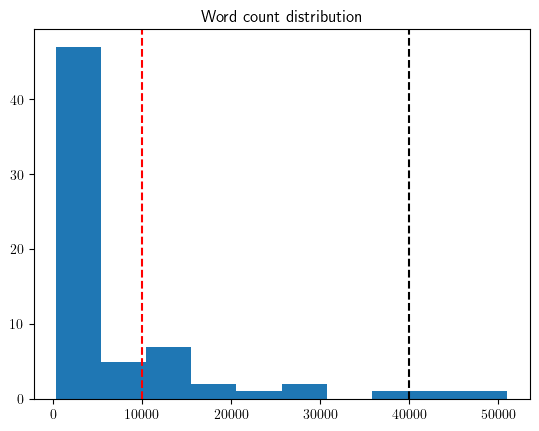

In [4]:
# word count histogram
plt.hist( biblio.df_texts['word_count'])  # creates a histogram of the word counts of the texts
plt.axvline( x = 1e4, color='red', linestyle='--', label='Novella' )
plt.axvline( x = 4e4, color='black', linestyle='--', label='Novel' )
plt.title('Word count distribution')

Text(0.5, 1.0, 'Sentence count distribution')

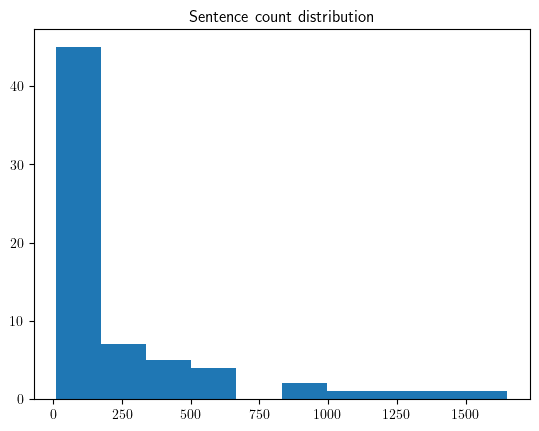

In [5]:
# sentence count histogram
plt.hist( biblio.df_texts['sentence_count'])  # creates a histogram of the sentence counts of the texts
plt.title('Sentence count distribution')

Text(0.5, 1.0, 'Vocabulary size distribution')

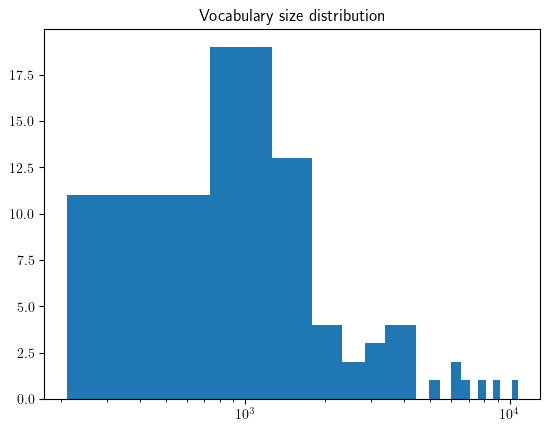

In [6]:
# vocabulary histogram
plt.hist( biblio.df_texts['vocabulary'], bins = 20)  # creates a histogram of the vocabulary sizes of the texts
plt.xscale('log')
plt.title('Vocabulary size distribution')

Text(0.5, 1.0, 'Character count distribution')

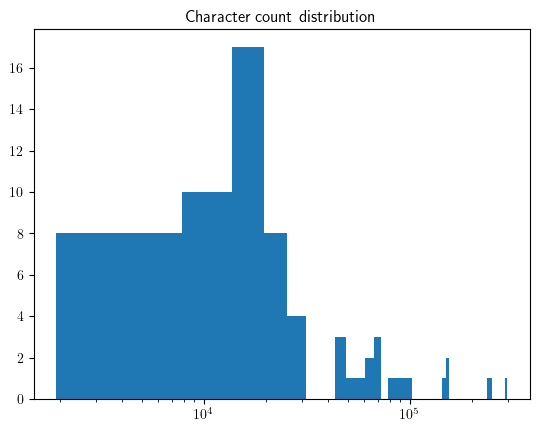

In [7]:
# character count histogram
plt.hist( biblio.df_texts['character_count'], bins = 50)  # creates a histogram of the character counts of the texts
plt.xscale('log') 
plt.title('Character count distribution')

Text(0.5, 1.0, 'Vocabulary to word count ratio distribution')

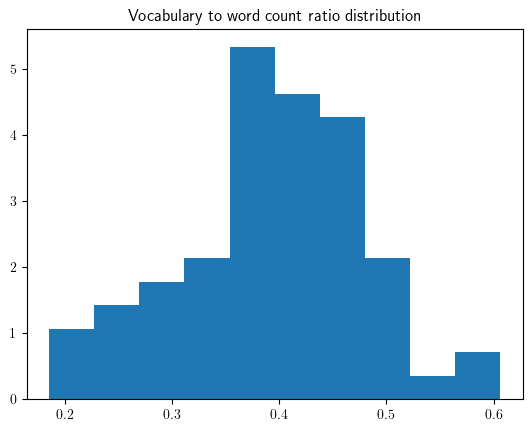

In [8]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

plt.hist( vocab_to_word, density=True )  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary to word count ratio distribution')

Text(0.5, 1.0, 'Vocabulary to sentence count ratio distribution')

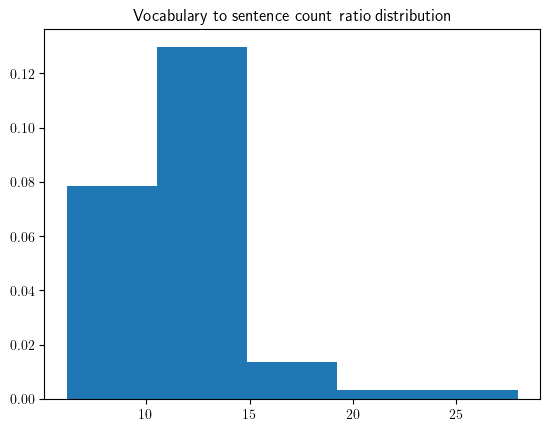

In [ ]:
# vocabulary to sentence count 

vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']

plt.hist(vocabulary_to_sentence, density=True, bins= 5)
plt.title('Vocabulary to sentence count ratio distribution') 

## 1.1. Vocabulary to word analysis

Here we perform a statiscal analysis and curve fitting for the vocabulary to word distribution

In [ ]:
text_tools.dist_statistics(vocab_to_word)

{'mean': 0.3939,
 'standard_deviation': 0.0852,
 'distribution_mode': 0.1857,
 'distribution_median': 0.3969,
 'distribution_skew': -0.1634,
 'distribution_kurt': 0.1238}

Possible candidates for this distributions are the distributions: gamma, beta, rayleigh, lognorm and chi2. Therefore we create a dictionary with each distribution and plot them below to visualize

/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


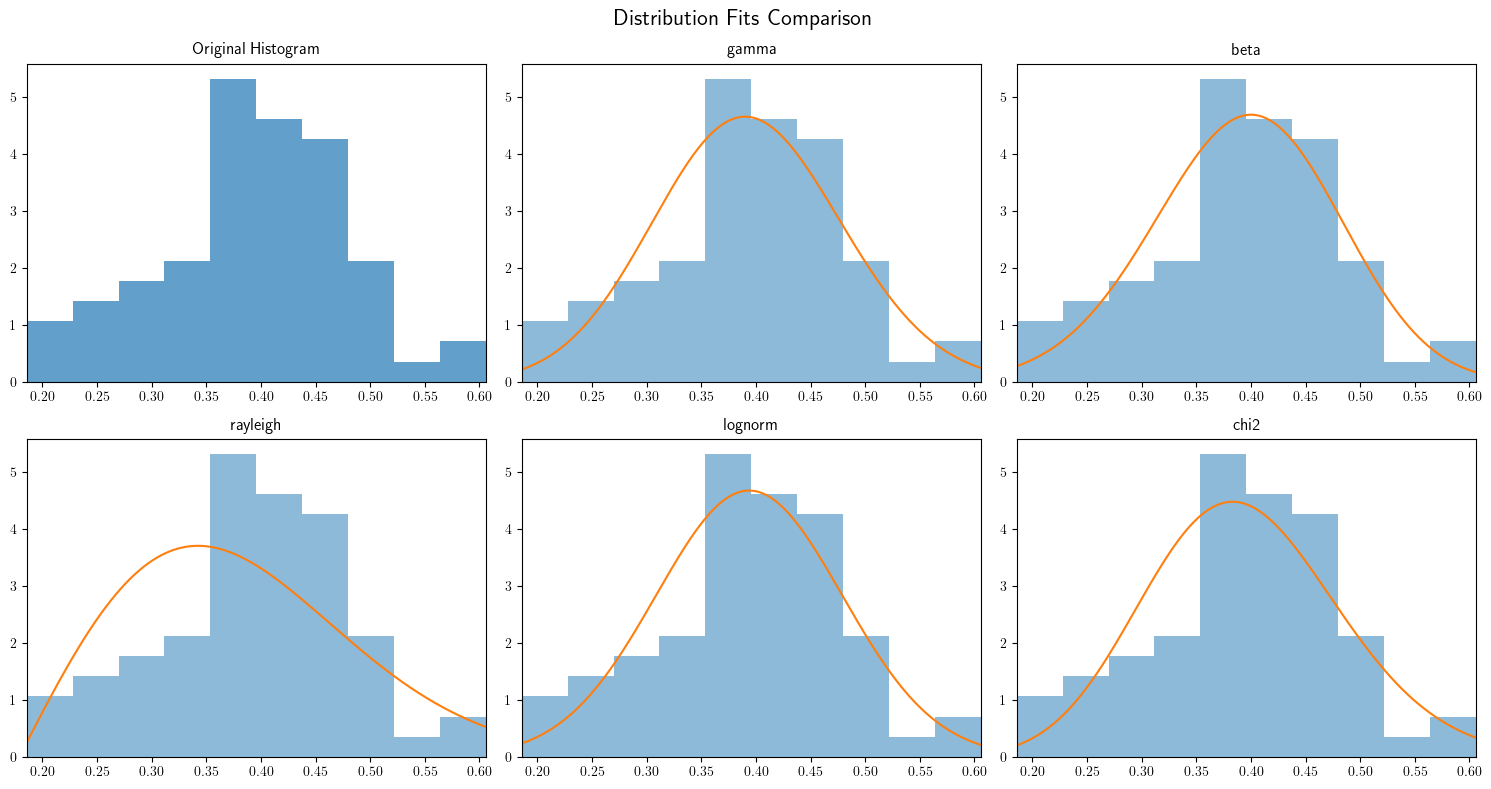

In [10]:
distributions = {
    "gamma": stats.gamma,
    "beta": stats.beta,
    "rayleigh": stats.rayleigh,
    "lognorm": stats.lognorm,
    "chi2": stats.chi2
}

# eixo comum
x = np.linspace(min(vocab_to_word), max(vocab_to_word), 1000)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(vocab_to_word, bins=10, density=True, alpha=0.7)
axes[0].set_title('Original Histogram')

for i, (name, dist) in enumerate(distributions.items(), start=1):
    ax = axes[i]
    
    # histograma
    ax.hist(vocab_to_word, bins=10, density=True, alpha=0.5)
    
    # fit
    params = dist.fit(vocab_to_word)
    pdf = dist.pdf(x, *params)
    
    # plot
    ax.plot(x, pdf)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(vocab_to_word), max(vocab_to_word))

plt.suptitle('Distribution Fits Comparison', fontsize=16)
plt.tight_layout()
plt.show()

Now we perform the fit using the Kolmogorov-Smirnov test

In [11]:
results = {}

for name, dist in distributions.items():
    # Fit dos parâmetros
    params = dist.fit(vocab_to_word)
    
    # Teste KS
    ks_stat, p_value = stats.kstest(vocab_to_word, name, args=params)
    
    results[name] = {
        "params": params,
        "ks_stat": ks_stat,
        "p_value": p_value
    }

# test cramer von mises

# shapiro wilk (gaussianity)
    

The results are

In [12]:
# Results 

for name, res in results.items():
    print(f"{name}: p-value = {res['p_value']:.4f}")

gamma: p-value = 0.7111
beta: p-value = 0.8535
rayleigh: p-value = 0.0219
lognorm: p-value = 0.7563
chi2: p-value = 0.7196


Since beta has the highets p-value, we compare it now with what we had

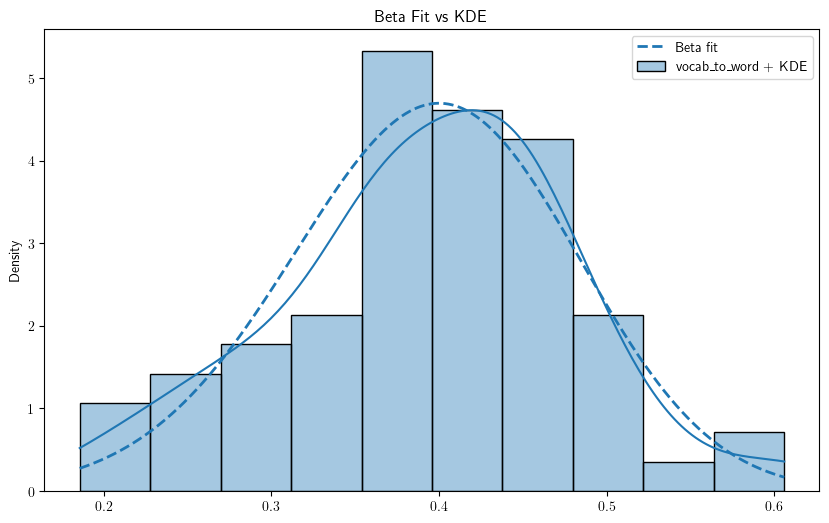

In [13]:
from scipy.stats import beta

# fit da beta
params = beta.fit(vocab_to_word)

# PDF da beta ajustada
beta_pdf = beta.pdf(x, *params)

# plot
plt.figure(figsize=(10, 6))

# histograma + KDE (seaborn)
sns.histplot(vocab_to_word, bins=10, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# beta ajustada
plt.plot(x, beta_pdf, label='Beta fit', linewidth=2, linestyle = 'dashed')

plt.title('Beta Fit vs KDE')
plt.legend()
plt.show()

## 1.2. Vocabulary to sentence analysis

Here we perform a statiscal analysis and curve fitting for the vocabulary to sentence distribution

Text(0.5, 1.0, 'Vocabulary to sentence count ratio distribution')

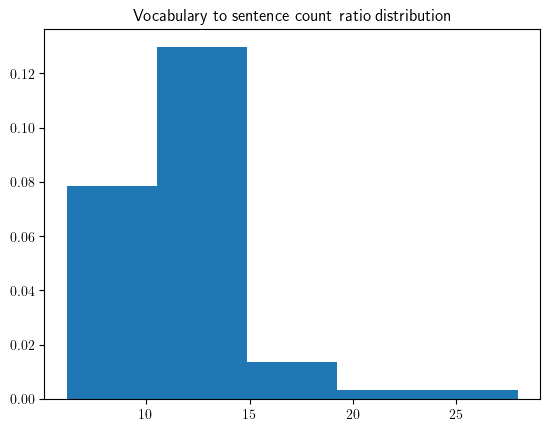

In [4]:
# vocabulary to sentence count 

vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']

plt.hist(vocabulary_to_sentence, density=True, bins= 5)
plt.title('Vocabulary to sentence count ratio distribution') 

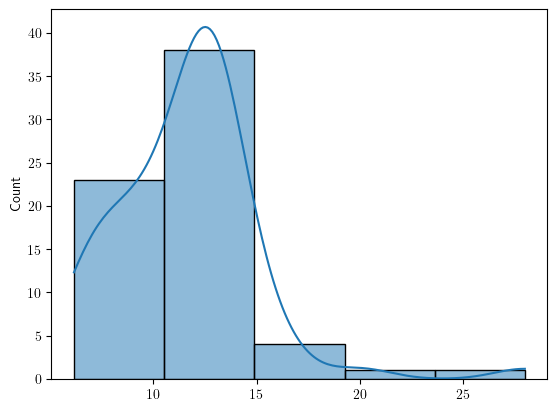

In [15]:
sns.histplot(vocabulary_to_sentence, kde= True, bins=5)
plt.show()

In [ ]:
from scipy.special import gamma as gamma_func  


k = np.linspace(min(vocabulary_to_sentence), max(vocabulary_to_sentence), 1000)
distribution_statistics = dist_statistics(vocabulary_to_sentence)
lambda_poisson = 12
poisson = (lambda_poisson ** k)*(np.exp(-lambda_poisson))/gamma_func(k+1)


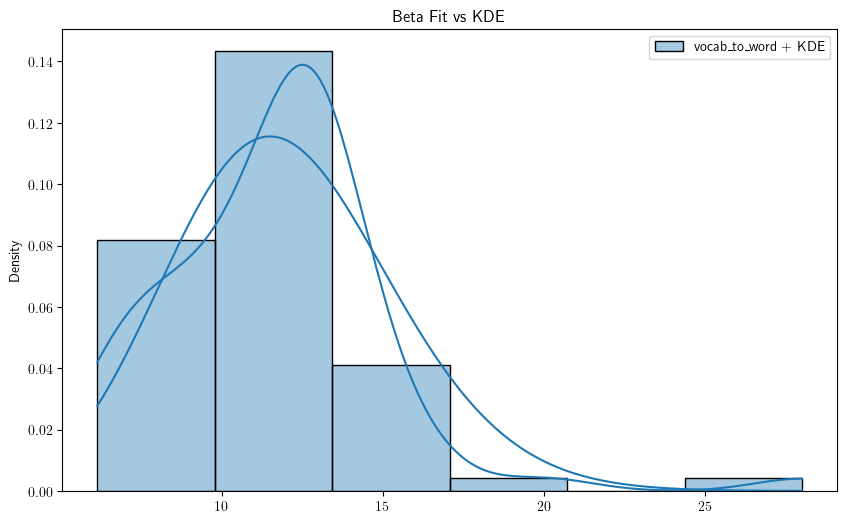

In [ ]:

# plot
plt.figure(figsize=(10, 6))

# histograma + KDE (seaborn)
sns.histplot(vocabulary_to_sentence, bins=6, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# poisson 

plt.plot(k, poisson)

plt.title('Beta Fit vs KDE')
plt.legend()
plt.show()

Possible candidates to fit this distribution are the Poisson and exponential. Now we do the same process

In [ ]:
distributions = {
    "gamma": stats.gamma,
    "expon": stats.expon,
    'chi2': stats.chi2,
    'beta': stats.beta
}

results = {}

for name, dist in distributions.items():
    # Fit dos parâmetros
    params = dist.fit(vocabulary_to_sentence)
    
    # Teste KS
    ks_stat, p_value = stats.kstest(vocabulary_to_sentence, name, args=params)
    
    results[name] = {
        "params": params,
        "ks_stat": ks_stat,
        "p_value": p_value
    }

for name, res in results.items():
    print(f"{name}: p-value = {res['p_value']:.4f}")

gamma: p-value = 0.1820
expon: p-value = 0.0012
chi2: p-value = 0.0062
beta: p-value = 0.1660


/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


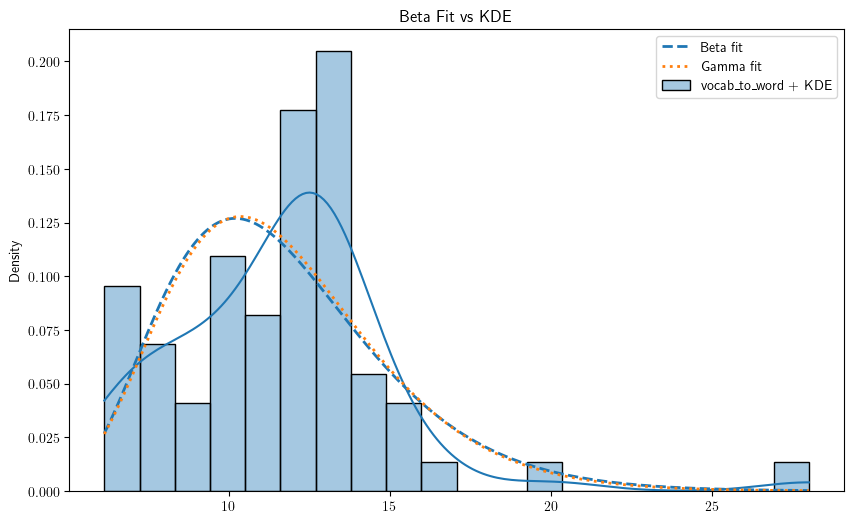

In [ ]:
from scipy.stats import beta
from scipy.stats import gamma

# fit da beta
params_beta = beta.fit(vocabulary_to_sentence)
params_gamma = gamma.fit(vocabulary_to_sentence)

# PDF da beta ajustada
beta_pdf = beta.pdf(k, *params_beta)

# PDF da gamma

gamma_pdf = gamma.pdf(k, *params_gamma)

# plot
plt.figure(figsize=(10, 6))

# histograma + KDE (seaborn)
sns.histplot(vocabulary_to_sentence, bins=20, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# beta ajustada
plt.plot(k, beta_pdf, label='Beta fit', linewidth=2, linestyle = 'dashed')
plt.plot(k, gamma_pdf, label = 'Gamma fit', linewidth =2, linestyle = ':')

plt.title('Beta Fit vs KDE')
plt.legend()
plt.show()

### Vocabulary to word distribution for each story 

In [ ]:
biblio.df_texts

,text,file,sentence_count,word_count,vocabulary,character_count
0,dreams_in_the_witch,dreams_in_the_witch.txt,546,14626,4148,86779
1,ex_oblivione,ex_oblivione.txt,21,701,348,3814
2,poetry_of_gods,poetry_of_gods.txt,56,1866,862,10560
3,doorstep,doorstep.txt,422,10446,3297,60265
4,colour_out_of_space,colour_out_of_space.txt,500,12134,3475,68090
...,...,...,...,...,...,...
62,cthulhu,cthulhu.txt,416,11777,3937,69371
63,beyond_wall_of_sleep,beyond_wall_of_sleep.txt,139,4283,1770,24900
64,high_house_mist,high_house_mist.txt,106,3626,1364,20238
65,rats_walls,rats_walls.txt,279,7822,2721,45550
